## Oil: Mean Reversion vs Trending Regimes 

Oil is one of the most analyzed commodities in the world, yet it remaines notoriously difficult to model. Prices are driven by a volatile mix of geopolitical events, OPEC policy decisions, demand cycles, and supply shocks, and often all at once. 

This notebook dives deeper into the statistical properties of WTI crude oil returns, asking a deceptively simple question: does oil trend, or does it mean revert? 

The answer depends entirely on when you're asking. 

We will be examining oil through three lenses: 
- **Stationarity** - Is the series even modelable? 
- **Hurst Exponent** - does it trend, mean revert, or random walk? 
- **Volatility and Return Distribution** - how extreme are the moves, and what do the tails look like? 

Throughout, we compare WTI against gold as a reference asset: a commodity with fundamentally different market dynamics, and we'll see a very different statistical fingerprint. 

In [1]:
# Setup and Data
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller, acf
import warnings 
import scipy.stats as stats
from hurst import compute_Hc 
import matplotlib.patches as mpatches 
import matplotlib.lines as mlines 

warnings.filterwarnings('ignore')

In [2]:
 
def get_series_from_yf(ticker: str):
    d = yf.download(ticker)['Close']
    d = d[d > 0]
    d = d.dropna() 
    print(f"Date Range: {d.index.min().date()} to {d.index.max().date()}") 
    return d


wti = get_series_from_yf('CL=F')
gold = get_series_from_yf('GC=F') 

wti_log_returns = np.log(wti).diff().dropna().squeeze() 
gold_log_returns = np.log(gold).diff().dropna().squeeze()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Date Range: 2000-08-23 to 2026-03-12


[*********************100%***********************]  1 of 1 completed

Date Range: 2000-08-30 to 2026-03-12


WTI's kurtosis of 16 is the standout number. Both assets exhibit fat tails well beyond what a normal distribution would predict, but oil's extreme kurtosis reflects a market that periodically produces catastrophic outliers, the 2020 negative price being the most extreme. Gold's kurtosis of 7, while still fat-tailed, is comparatively tame.

WTI is nearly symmetric (skew: -0.031). Extreme moves occur in both directions. Gold skews negative (-0.467), suggesting more frequent small gains but asymmetric downside when it moves against you.

The practical implication: standard risk models assuming normality will underestimate tail risk for both assets, but catastrophically so for oil.

In [3]:
print(f"Date Range: {wti.index.min().date()} to {wti.index.max().date()}")

Date Range: 2000-08-23 to 2026-03-12


Most statistical models assume that the data they're working with has a stable mean and variance over time. Raw oil prices don't, they drift, spike, crash. Running models on non-stationary data produce spurious results that look meaningful but aren't. Before any analysis, we confirm that WTI log returns are stationary using the Augmented Dickey-Fuller (ADF) Test. 

If the series is non-stationary, any patterns we find such as correlations, volatility clustering, regime behavior, could just be an artifact of the drift and not real structural feature of the market. We would be modelling noise and calling it a signal. 

Hypothesis: Log Returns are stationary while prices are non stationary. 

This is also why practitioners use log returns as features in financial ML models rather than raw prices as stationarity is not just a statistical formality, it's a modelling prerequisite. 

In [4]:

def run_adf(series: pd.Series | pd.DataFrame, label: str): 
    result = adfuller(series.dropna()) 
    print(f"{label}: ADF stat={result[0]:.4f}, p={result[1]:.4f}")
    print(f"  Critical values: {result[4]}")
    return result 

price_result = run_adf(wti, "WTI Price Level")
log_returns_result = run_adf(wti_log_returns, "WTI Log Returns")

WTI Price Level: ADF stat=-2.7997, p=0.0583
  Critical values: {'1%': np.float64(-3.4313747386176345), '5%': np.float64(-2.861992845269893), '10%': np.float64(-2.567011046366896)}
WTI Log Returns: ADF stat=-13.1139, p=0.0000
  Critical values: {'1%': np.float64(-3.431375220588153), '5%': np.float64(-2.8619930582221804), '10%': np.float64(-2.5670111597262393)}


In [5]:
def format_adf(result: tuple):
    # null hypothesis is rejected when the adf test stat is more negative than the critical value 
    # or p value < 0.05 
    adf_stat, p_value, lags, nobs, critical_values, _ = result
    
    print(f"ADF Statistic:  {adf_stat:.4f}")
    print(f"p-value:        {p_value}")
    print(f"Lags used:      {lags}")
    print(f"Observations:   {nobs}")
    print(f"Critical Values:")
    for level, val in critical_values.items():
        reject = "✓" if adf_stat < val else "✗"
        print(f"  {level}: {val:.4f}  {reject}")
    print(f"\nStationary: {'Yes' if p_value < 0.05 else 'No'}")

In [6]:
format_adf(log_returns_result)
# analysis: 
# Oil log returns are stationary
# mean, variance, and autocorrelation structure don't change overtime 

ADF Statistic:  -13.1139
p-value:        1.6137489719762126e-24
Lags used:      31
Observations:   6381
Critical Values:
  1%: -3.4314  ✓
  5%: -2.8620  ✓
  10%: -2.5670  ✓

Stationary: Yes


In [7]:
format_adf(price_result)

ADF Statistic:  -2.7997
p-value:        0.05832063294459119
Lags used:      29
Observations:   6384
Critical Values:
  1%: -3.4314  ✗
  5%: -2.8620  ✗
  10%: -2.5670  ✓

Stationary: No


ADF test results confirm the hypothesis that WTI price levels fail to reject the null hypothesis at 5% significance level (p=0.056), indicating non-stationarity. The series drifts and has no stable mean to revert to. 

Log returns tell a different story, with an ADF statistic of -13.15 and a p-value of essentially zero, we reject the null decisively. The series is stationary at all conventional significance levels: 1%, 5%, and 10%. 

Downstream analysis will utilize oil log returns. 

In [8]:
price_result = run_adf(gold, "GOLD Price Level")
log_returns_result = run_adf(gold_log_returns, "GOLD Log Returns")

GOLD Price Level: ADF stat=5.1793, p=1.0000
  Critical values: {'1%': np.float64(-3.4313766692238055), '5%': np.float64(-2.8619936982824394), '10%': np.float64(-2.5670115004449)}
GOLD Log Returns: ADF stat=-25.4614, p=0.0000
  Critical values: {'1%': np.float64(-3.431373135316956), '5%': np.float64(-2.8619921368724857), '10%': np.float64(-2.5670106692708963)}


Both WTI and Gold log returns are confirmed stationary. This tells us the series have stable statistical properties over time. However, stationarity alone doesn't tell us anything about the structure of returns. Are past returns informative about future returns? i.e. - Is there any momentum? or are there any mean reversion tendencies? To test, we calculate the Hurst exponent for the entire series, and a rolling Hurst exponent to explore how the series evolves over time. 

In [9]:
# Hurst exponent 

H_oil, c, data = compute_Hc(wti_log_returns.dropna(), kind='change', simplified=True) 
H_gold, _, _ = compute_Hc(gold_log_returns, kind='change', simplified=True) 
print(f"Oil Hurst Exponent: {H_oil:.4f}") 
print(f"Gold Hurst Exponent: {H_gold:.4f}")

Oil Hurst Exponent: 0.5033
Gold Hurst Exponent: 0.6260


WTI crude oil has a Hurst exponent of 0.503, statistically indistinguishable from 0.5, indicating that oil log returns behave as a random walk. Past returns carry no meaningful information about future direction. 

Gold tells a different story. At 0.626, gold log returns exhibit genuine persistence, aka, the series trends. Positive returns tend to be followed by positive returns, and vice versa. This is not a marginal result, 0.626 is a meaningful deviation from 0.5. 

This divergence has practical implications. It suggests that trend-following strategies have a statistical basis in gold markets that simply don't exist in oil. 

However, this is a single static estimate across the entire sample and tells us nothing about how the Hurst exponent evolves over time. It doesn't inform us whether the trending behavior in gold strengthens or breaks down during market shocks, or whether oil occasionally exhibits momentum during specific regimes. To investigate that, we compute a rolling Hurst exponent. 

In [10]:
def rolling_hurst(series, window=252):
    result = pd.Series(index=series.index, dtype=float)
    for i in range(window, len(series)):
        window_data = series.iloc[i-window:i]
        try:
            H, _, _ = compute_Hc(window_data, kind='change', simplified=True)
            result.iloc[i] = H
        except:
            result.iloc[i] = np.nan
    return result


The static Hurst gives us a single number across the entire sample. Useful as a baseline, but it masks how market structure evolves over time. To capture regime dynamics, we compute a 252-day rolling Hurst exponent alongside a rolling volatility for both WTI and gold. 

A 252-day window corresponds to one trading year, the most natural lookback in finance for annualized statistics, and long enough for the Hurst estimation to converge reliably without being so long that it obscures regime transitions.

In [11]:

rolling_window = 252
gold_rolling_hurst = rolling_hurst(gold_log_returns, rolling_window) 
oil_rolling_hurst = rolling_hurst(wti_log_returns, rolling_window) 

rolling_hurst_comparison = pd.DataFrame({
    'gold': gold_rolling_hurst, 
    'oil': oil_rolling_hurst
})

# gold_log_returns = np.log(gold / gold.shift(1)).squeeze()
# oil_log_returns = np.log( / wti_clean.shift(1)).squeeze()

gold_rolling_volatility = gold_log_returns.rolling(rolling_window).std().squeeze()
oil_rolling_volatility = wti_log_returns.rolling(rolling_window).std().squeeze()
# Reindex gold to match oil
gold_rolling_volatility = gold_rolling_volatility.reindex(oil_rolling_volatility.index)

rolling_volatility_comparison = pd.DataFrame({
    'gold': gold_rolling_volatility,
    'oil': oil_rolling_volatility
})

In [12]:

summary = pd.DataFrame({
    'oil_hurst':      oil_rolling_hurst,
    'gold_hurst':     gold_rolling_hurst,
    'oil_vol':        oil_rolling_volatility,
    'gold_vol':       gold_rolling_volatility,
    'oil_hurst_chg':  oil_rolling_hurst.diff().abs(),
    'gold_hurst_chg': gold_rolling_hurst.diff().abs(),
    'oil_vol_chg':    oil_rolling_volatility.diff().abs(),
    'gold_vol_chg':   gold_rolling_volatility.diff().abs(),
}).dropna()

metrics = {
    'Highest Oil Volatility':       ('oil_vol',        False),
    'Highest Gold Volatility':      ('gold_vol',       False),
    'Highest Oil Hurst':            ('oil_hurst',      False),
    'Lowest Oil Hurst':             ('oil_hurst',      True),
    'Highest Gold Hurst':           ('gold_hurst',     False),
    'Lowest Gold Hurst':            ('gold_hurst',     True),
    'Biggest Oil Vol Change':       ('oil_vol_chg',    False),
    'Biggest Gold Vol Change':      ('gold_vol_chg',   False),
    'Biggest Oil Hurst Change':     ('oil_hurst_chg',  False),
    'Biggest Gold Hurst Change':    ('gold_hurst_chg', False),
}

for title, (col, asc) in metrics.items():
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(summary[[col]].sort_values(col, ascending=asc).head(10).to_string())


  Highest Oil Volatility
             oil_vol
Date                
2020-06-29  0.070178
2020-07-01  0.070177
2020-06-30  0.070175
2020-06-25  0.070170
2020-06-11  0.070159
2020-06-24  0.070159
2020-06-16  0.070150
2020-06-17  0.070150
2020-06-26  0.070148
2020-06-19  0.070141

  Highest Gold Volatility
            gold_vol
Date                
2009-03-19  0.020650
2009-03-24  0.020643
2009-03-26  0.020639
2009-03-25  0.020637
2009-03-27  0.020633
2009-03-30  0.020616
2009-03-23  0.020581
2009-03-20  0.020580
2009-04-07  0.020571
2009-04-06  0.020565

  Highest Oil Hurst
            oil_hurst
Date                 
2021-04-29   0.769474
2015-04-24   0.767323
2015-04-23   0.767170
2021-04-28   0.766318
2015-04-27   0.765175
2021-04-30   0.764260
2015-03-30   0.761930
2015-05-18   0.759627
2015-05-15   0.759478
2015-04-28   0.758766

  Lowest Oil Hurst
            oil_hurst
Date                 
2017-08-23   0.303263
2017-08-22   0.305688
2017-08-09   0.307997
2017-09-06   0.314974
2017-0

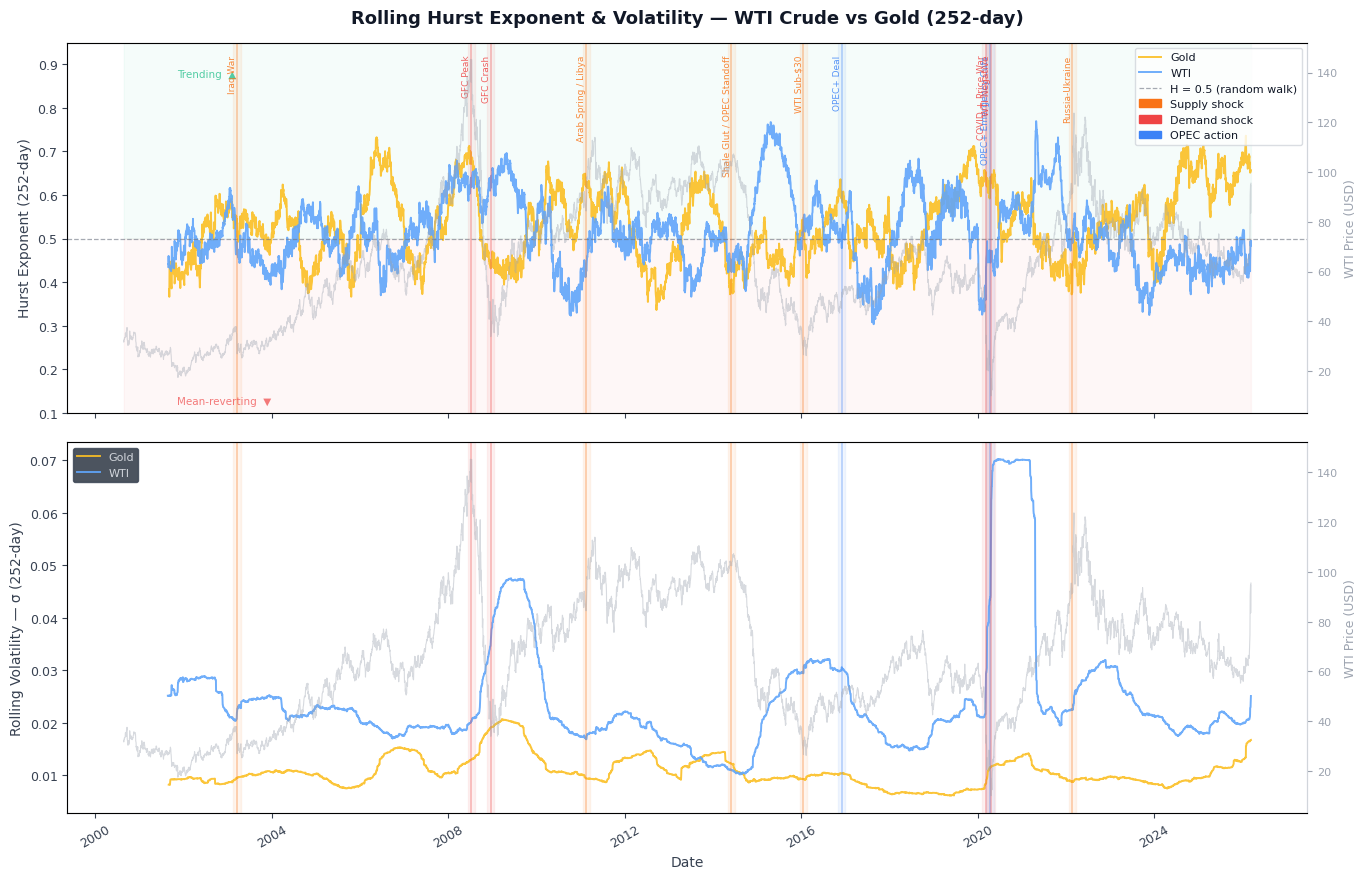

In [13]:


events = {
    '2003-03-20': ('Iraq War',                    'supply'),
    '2008-07-11': ('GFC Peak',                    'demand'),
    '2008-12-19': ('GFC Crash',                   'demand'),
    '2011-02-17': ('Arab Spring / Libya',          'supply'),
    '2014-06-01': ('Shale Glut / OPEC Standoff',  'supply'),
    '2016-01-20': ('WTI Sub-$30',                 'supply'),
    '2016-11-30': ('OPEC+ Deal',                  'opec'),
    '2020-03-08': ('COVID + Price War',            'demand'),
    '2020-04-12': ('OPEC+ Emergency Cuts',         'opec'),
    '2020-04-20': ('WTI Negative',                'demand'),
    '2022-02-24': ('Russia-Ukraine',              'supply'),
}

COLOR = {
    'supply': '#F97316',   # orange
    'demand': '#EF4444',   # red
    'opec':   '#3B82F6',   # blue
}

ALPHA_VLINE = 0.35
ALPHA_BAND  = 0.07
LW_VLINE    = 1.2

fig, axes = plt.subplots(
    2, 1, figsize=(16, 10),
    sharex=True,
    gridspec_kw={'hspace': 0.08, 'height_ratios': [1, 1]}
)

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='#374151', labelsize=9)
    ax.yaxis.label.set_color('#374151')
    for spine in ax.spines.values():
        spine.set_edgecolor('#D1D5DB')

ax0 = axes[0]

ax0.plot(rolling_hurst_comparison.index,
         rolling_hurst_comparison['gold'],
         color='#FBBF24', lw=1.4, label='Gold', alpha=0.9)

ax0.plot(rolling_hurst_comparison.index,
         rolling_hurst_comparison['oil'],
         color='#60A5FA', lw=1.4, label='WTI', alpha=0.9)

ax0.axhline(0.5, color='#6B7280', lw=0.9, ls='--', alpha=0.6, label='H = 0.5 (random walk)')
ax0.fill_between(rolling_hurst_comparison.index, 0.5, 1.0,
                 alpha=0.04, color='#10B981')   # trending zone
ax0.fill_between(rolling_hurst_comparison.index, 0.0, 0.5,
                 alpha=0.04, color='#EF4444')   # mean-reverting zone

ax0.set_ylabel('Hurst Exponent (252-day)', fontsize=10)
ax0.set_ylim(0.1, 0.95)
ax0.legend(loc='upper left', fontsize=8,
           facecolor='#1F2937', edgecolor='#374151', labelcolor='#D1D5DB')

# small zone labels
ax0.text(rolling_hurst_comparison.index[300], 0.87,
         'Trending  ▲', color='#10B981', fontsize=7.5, alpha=0.7)
ax0.text(rolling_hurst_comparison.index[300], 0.12,
         'Mean-reverting  ▼', color='#EF4444', fontsize=7.5, alpha=0.7)

ax0_price = ax0.twinx()
ax0_price.plot(wti.index, wti.values,
               color='#9CA3AF', lw=0.8, alpha=0.4, label='WTI Price')
ax0_price.set_ylabel('WTI Price (USD)', fontsize=9, color='#9CA3AF')
ax0_price.tick_params(colors='#9CA3AF', labelsize=8)
ax0_price.spines['right'].set_edgecolor('#D1D5DB')
         

ax1 = axes[1]

ax1.plot(rolling_volatility_comparison.index,
         rolling_volatility_comparison['gold'],
         color='#FBBF24', lw=1.4, label='Gold', alpha=0.9)

ax1.plot(rolling_volatility_comparison.index,
         rolling_volatility_comparison['oil'],
         color='#60A5FA', lw=1.4, label='WTI', alpha=0.9)

ax1.set_ylabel('Rolling Volatility — σ (252-day)', fontsize=10)
ax1.legend(loc='upper left', fontsize=8,
           facecolor='#1F2937', edgecolor='#374151', labelcolor='#D1D5DB')

ax1_price = ax1.twinx()
ax1_price.plot(wti.index, wti.values,
               color='#9CA3AF', lw=0.8, alpha=0.4, label='WTI Price')
ax1_price.set_ylabel('WTI Price (USD)', fontsize=9, color='#9CA3AF')
ax1_price.tick_params(colors='#9CA3AF', labelsize=8)
ax1_price.spines['right'].set_edgecolor('#D1D5DB')

label_y_hurst  = 0.91   # fractional axis coords for text
label_y_vol    = 0.93

for date_str, (label, etype) in events.items():
    dt = pd.Timestamp(date_str)
    c  = COLOR[etype]

    for ax in axes:
        ax.axvline(dt, color=c, lw=LW_VLINE, alpha=ALPHA_VLINE, zorder=2)
        ax.axvspan(dt - pd.Timedelta(days=30),
                   dt + pd.Timedelta(days=30),
                   color=c, alpha=ALPHA_BAND, zorder=1)

    # stagger labels so they don't pile up — alternate top ax only
    ax0.text(dt, ax0.get_ylim()[1] * 0.97,
             label, color=c, fontsize=6.5,
             rotation=90, va='top', ha='right', alpha=0.85)

legend_handles = [
    mpatches.Patch(color=COLOR['supply'], label='Supply shock'),
    mpatches.Patch(color=COLOR['demand'], label='Demand shock'),
    mpatches.Patch(color=COLOR['opec'],   label='OPEC action'),
]
ax0.legend(
    handles=ax0.get_legend().legend_handles + legend_handles,
    loc='upper right', fontsize=8,
    facecolor='white', edgecolor='#D1D5DB', labelcolor='#111827',
)

ax0.set_title(
    'Rolling Hurst Exponent & Volatility — WTI Crude vs Gold (252-day)',
    color='#111827', fontsize=13, fontweight='bold', pad=14
)
ax1.set_xlabel('Date', color='#374151', fontsize=10)

ax1.xaxis.set_tick_params(rotation=30)

plt.tight_layout()
plt.show()

Baseline observation: WTI consistently exhibits higher rolling volatility than gold across the entire sample. This is a structural feature of oil markets, subject to supply shocks, geopolitical disruptions, OPEC policy swings, and demand cycles that gold simply exposed to in the same way. Gold volatility spikes during risk-off episodes but revers. Oil volatility is higher on average and more persistent following shocks. 


Rolling Hurst + Volatility (Key Observations)
1. Iraqi War (2003) - mild Hurst shift from trending to mean-reverting for WTI, not dramatic. Volatility spike was negligible. Anticipated geopolitical event, no real supply disruption. 
2. GFC (2008) - WTI Hurst remained elevated at 0.6-0.7 during the commodity supercycle peak. Volatility started rising at GFC onset for both assets, peaked after the crash, lagged rolling window effect. Hurst exponent began neutralizing to 0.5, followed by a drop in volatility. 
3. Shale Glut / OPEC Standoff (2014-2016) - WTI Hurst spiked to 0.8 reflecting sustained trending downside regime as oil collapsed from $105 to sub-$30. This was a trending crash and not a random panic. Hurst normalized back to 0.5 when oil hit sub-$30 lows. During this time, oil volatility peaked, and started to taper down in November 2016 as the OPEC+ deal marked the end of the regime.
4. Covid (2020) - WTI Hurst recovered from 0.3 to 0.5 as the shock hit, while volatility spiked to its largest level in the entire sample. The demand destruction was sudden and severe as lockdowns wiped out mobility and industrial activity overnight, collapsing oil demand and ultimately driving WTI futures briefly negative in April 2020. Post-COVID volatility remained structurally elevated. 
5. Strait of Hormuz Tensions (2026) - supply threat with no realized disruption. Ranks in the top 50 largest single-day vol changes across 24 years of data, but sits an order of magnitude below the COVID shock. Consistent with the Iraq War 2003 pattern, geopolitical supply threats register, but realized demand destruction dominates.

General Observations 
- Oil's peak rolling volatility (σ = 0.070) occurred in June 2020, roughly 3x higher than gold's peak (σ = 0.021) in March 2009. Two different assets, two different shock types — demand destruction vs post-GFC safe-haven unwinding.
- Oil's highest Hurst readings (0.769) occurred in both April 2015 and April 2021 — two distinct trending regimes in opposite directions. 2015 was a trending crash, 2021 was a trending recovery post-COVID.
- Oil's lowest Hurst (0.303) occurred in August 2017, the post-OPEC+ deal stabilization period. Markets had found equilibrium and directional memory collapsed.
- Gold is currently (January 2026) in its strongest trending regime in the entire 24-year sample, with a rolling Hurst of 0.736. The current run exceeds even the 2006 commodity supercycle peak.
- Low volatility periods broadly correspond to mean-reverting Hurst regimes across both assets. Calm markets lack sustained directional force — returns oscillate rather than trend.
- The largest single-day Hurst change in oil (0.092, April 2021) is a data artifact — the April 2020 negative price observation rolling out of the 252-day window, not a real market event.


In [14]:
raw_oil = yf.download('CL=F')['Close'] 
raw_gold = yf.download('GC=F')['Close'] 
raw_oil_log_returns = np.log(raw_oil).diff().dropna().squeeze() 
raw_gold_log_returns = np.log(raw_gold).diff().dropna().squeeze() 

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Beyond volatility, we examine the full distribution of log returns for both assets. Volatility tells us how much prices move. Distribution tells us the shape of those moves whether extreme events are rare anomalies or a structural feature of the market.

We plot without filtering outliers. The extremes are the point.

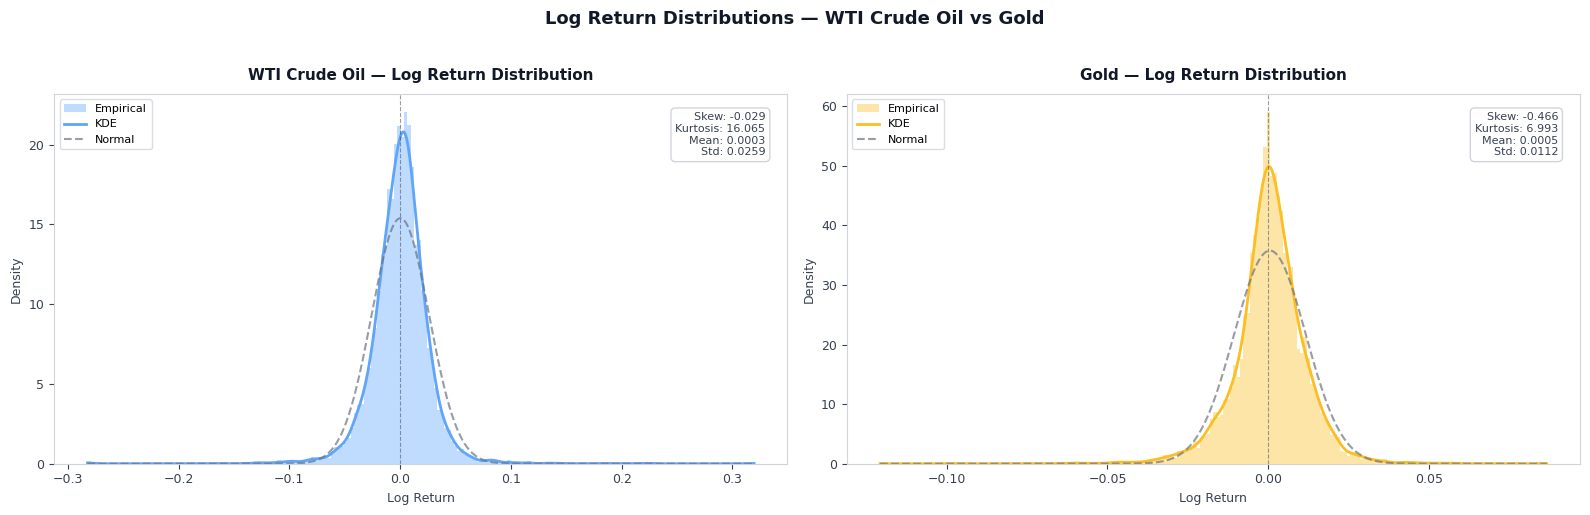

In [15]:


fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax, series, label, color in zip(
    axes,
    [raw_oil_log_returns, raw_gold_log_returns],
    ['WTI Crude Oil', 'Gold'],
    ['#60A5FA', '#FBBF24']
):
    ax.set_facecolor('white')
    ax.tick_params(colors='#374151', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#D1D5DB')

    data = series.dropna()

    ax.hist(data, bins=200, color=color, alpha=0.4, density=True, label='Empirical')

    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 1000)
    ax.plot(x, kde(x), color=color, lw=2, label='KDE')

    mu, std = data.mean(), data.std()
    ax.plot(x, stats.norm.pdf(x, mu, std),
            color='#6B7280', lw=1.5, ls='--', alpha=0.7, label='Normal')

    ax.axvline(0, color='#374151', lw=0.8, ls='--', alpha=0.5)

    skew = float(data.skew())
    kurt = float(data.kurtosis())
    ax.text(0.97, 0.95,
            f'Skew: {skew:.3f}\nKurtosis: {kurt:.3f}\nMean: {mu:.4f}\nStd: {std:.4f}',
            transform=ax.transAxes, fontsize=8,
            va='top', ha='right', color='#374151',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D1D5DB'))

    ax.set_title(f'{label} — Log Return Distribution',
                 fontsize=11, fontweight='bold', color='#111827', pad=10)
    ax.set_xlabel('Log Return', fontsize=9, color='#374151')
    ax.set_ylabel('Density', fontsize=9, color='#374151')
    ax.legend(fontsize=8, facecolor='white', edgecolor='#D1D5DB')

plt.suptitle('Log Return Distributions — WTI Crude Oil vs Gold',
             fontsize=13, fontweight='bold', color='#111827', y=1.02)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

WTI's kurtosis is a standout figure. Both assets exhibit fat tails well beyond what a normal distribution would predict. But oil's extreme kurtosis reflects a market that periodically produces catastrophic outliers. The 2020 negative price being the most extreme. Gold's kurtosis of 7, while still fat-tailed, is comparatively tame compared to oil. 

WTI is nearly symmetric (skew: -0.031). Extreme moves occur in both directions while Gold skews negative (-0.467), a reminder that safe haven status doesn't mean safe returns. Small positive days are the norm, but the left tail is heavier than most expect. 

The practical implication: standard risk models assuming normality will underestimate tail risk for both assets, but catastrophially so for oil. A model that assumes normally distributed returns would never anticipate a kurtosis-16 event. 

So, does oil trend or mean revert?

Both, but not at the same time, and not for the same reasons.

At the aggregate level, WTI log returns are a near-perfect random walk (H = 0.503). There is no persistent directional memory across the full 24-year sample. But that number masks everything interesting. The
rolling Hurst tells a different story: oil cycles through regimes of trending and mean reversion depending on what's driving the market. The 2014-2016 shale glut produced a sustained trending crash (H → 0.8). COVID produced chaos with no directional structure (H → 0.3). Calm periods revert.

Volatility follows a similar pattern. WTI is structurally more volatile than gold, but the shape of that volatility differs by shock type. Demand destruction in 2020 produced the largest vol spike in the sample, and the fattest tails, with a kurtosis of 16. Supply threats, by comparison, seem to barely register.

Gold, meanwhile, is a different asset entirely. A static Hurst of 0.626 confirms genuine trending behavior across the full sample, a statistical fingerprint that oil simply doesn't have.

The takeaway: oil is unpredictable on average, but structurally patterned during crises. The regimes are real. The question is whether you can identify them in time to act.